# Double distillation column: the infinite horizon vs the finite horizon

The model is the declared double column from [`models/double_column.py`](models/double_column.py):
two 41-tray columns in series separating a ternary mixture, the DAE example.
The weir flows, vapor compositions, tray temperatures, and purity aliases are
algebraic and undeclared; they ride along with the declared states. Two cases
of the same model. Case 1 runs five sampling steps with the infinite-horizon
terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs the full twenty-five step finite horizon with the
terminal cost live.

Both cases initialize before the solve (`initialize.py`): the states
interpolate linearly from the initial condition to the steady state, and
the algebraic and cost variables then come from their defining equations
at those states. A stand-in until initialization lands in drto.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.double_column import double_column
from drto import plot_states, plot_controls, plot_stage_cost
#import idaes
m1 = double_column(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
drto.cold_start_dynamic(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)
#pyo.SolverFactory("ipopt").solve(m1, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpl2mpfi_t.pyomo.nl...


Parsed 26906 vars, 26532 cons, jac_nnz=130415, h_nnz=61561 in 0.11s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   130255
Number of nonzeros in inequality constraint Jacobian.:      160
Number of nonzeros in Lagrangian Hessian.............:    61561

Total number of variables............................:    26906
                     variables with only lower bounds:     3003
                variables with lower and upper bounds:    16272
                     variables with only upper bounds:        0
Total number of equality constraints.................:    26500
Total number of inequality constraints...............:       32
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       32
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.1145021e+03 5.05e+00 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  2.9470478e+02 4.89e+00 9.55e+01   -1.0 2.07e+01      - 9.20e-02 3.16e-02f  1


   2  1.9472207e+03 3.80e+00 4.23e+02   -1.0 2.63e+01      - 1.66e-01 2.23e-01h  1


...

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  70  2.7168954e+02 5.09e-08 1.08e+00   -8.6 5.67e-04      - 9.76e-01 8.04e-01f  1


  71  2.7168952e+02 2.34e-09 3.40e-05   -8.6 2.35e-04      - 1.00e+00 1.00e+00f  1


  72  2.7168952e+02 9.19e-11 3.67e-08   -8.6 6.84e-05      - 1.00e+00 1.00e+00h  1


  73  2.7168952e+02 1.08e-11 4.21e-09   -8.6 2.38e-05      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 73

                                   (scaled)                 (unscaled)
Objective...............:   2.7168952061340764e+01    2.7168952061340764e+02
Dual infeasibility......:   4.2078375633531988e-09    4.2078375633531985e-08
Constraint violation....:   1.0820011553391851e-11    1.0820011553391851e-11
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.8598004103529447e-09    2.8598004103529446e-08
Overall NLP error.......:   4.2078375633531988e-09    4.2078375633531985e-08


Number of objective function evaluations             = 79
Number of objective gradient evaluations             = 74
Number of equality constraint evaluations            = 79
Number of inequality constraint evaluations          = 79
Number of equality constraint Jacobian evaluations   = 74
Number of inequality constraint Jacobian evaluations = 74
Nu

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 26532, 'Number of variables': 26906, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 67.21857976913452}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

<drto registry>
states: 606, controls: 8
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[i,t]  ==  L1[11,t] - L1[i,t] + VB1[0] - VB1[0]  for i in tray, t in t
  dynamics: dx1[i,j,t]  ==  (L1[11,t]*(x1[11,j,t] - x1[i,j,t]) + VB1[0]*(y1[9,j,t] - x1[i,j,t]) - VB1[0]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t]  for i in tray, j in comp, t in t
  dynamics: dM2[i,t]  ==  L2[11,t] - L2[i,t] + VB2[0] - VB2[0]  for i in tray, t in t
  dynamics: dx2[i,j,t]  ==  (L2[11,t]*(x2[11,j,t] - x2[i,j,t]) + VB2[0]*(y2[9,j,t] - x2[i,j,t]) - VB2[0]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t]  for i in tray, j in comp, t in t
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray))  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(SUM((x1[i,j,5] - x1_ss[i,j])**2 + (x2[i,j,5] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,5] - M1_ss[l])**2 + (M2[l,5] - M2_ss[l])**2 for l in tray))
  initial conditions: x1_hat[i,j]  ==  x1[i,j,0]  for i in tray, j in comp
  initial conditions: x2_hat[i,j]  ==  x2[i,j,0]  for i in tray, j in comp
  initial conditions: M1_hat[i]  ==  M1[i,0]  for i in tray
  initial conditions: M2_hat[i]  ==  M2[i,0]  for i in tray
  steady-state targets: x1_ss (of x1), x2_ss (of x2), M1_ss (of M1), M2_ss (of M2)
  steady-state control targets: LT1_ss (of LT1), VB1_ss (of VB1), D1_ss (of D1), B1_ss (of B1), LT2_ss (of LT2), VB2_ss (of VB2), D2_ss (of D2), B2_ss (of B2)
  cost_group: drto_ih, drto_ih
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, algebraic=9 components replicated, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=LT1 (piecewise_constant), VB1 (piecewise_constant), D1 (piecewise_constant), B1 (piecewise_constant), LT2 (piecewise_constant), VB2 (piecewise_constant), D2 (piecewise_constant), B2 (piecewise_constant)
  drto.build_objective: objective=sum of 1004 weighted cost terms

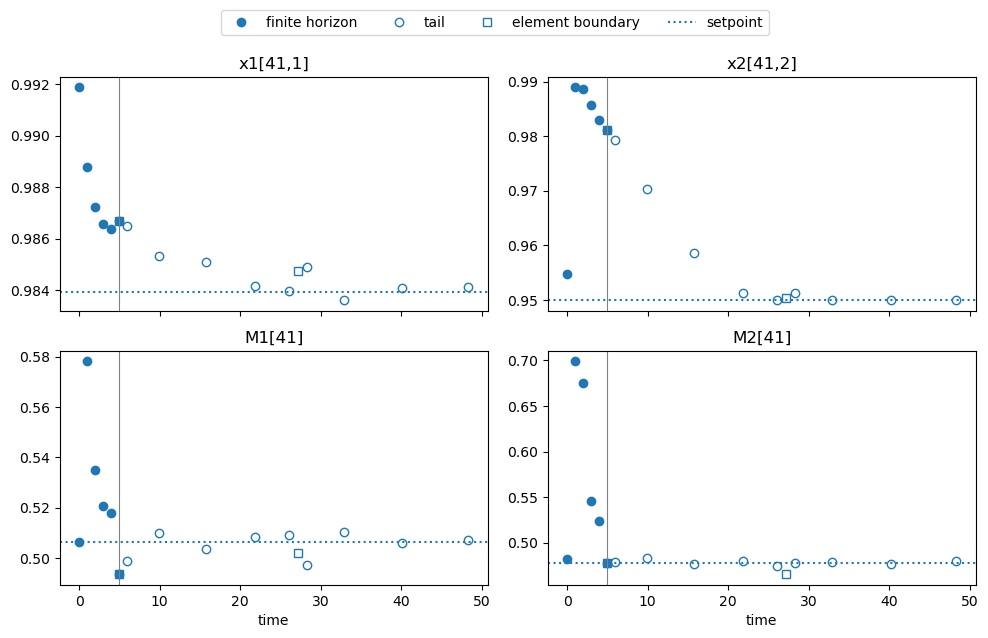

In [3]:
# multi-index states select by member: overhead purities and condenser holdups
plot_states(m1, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

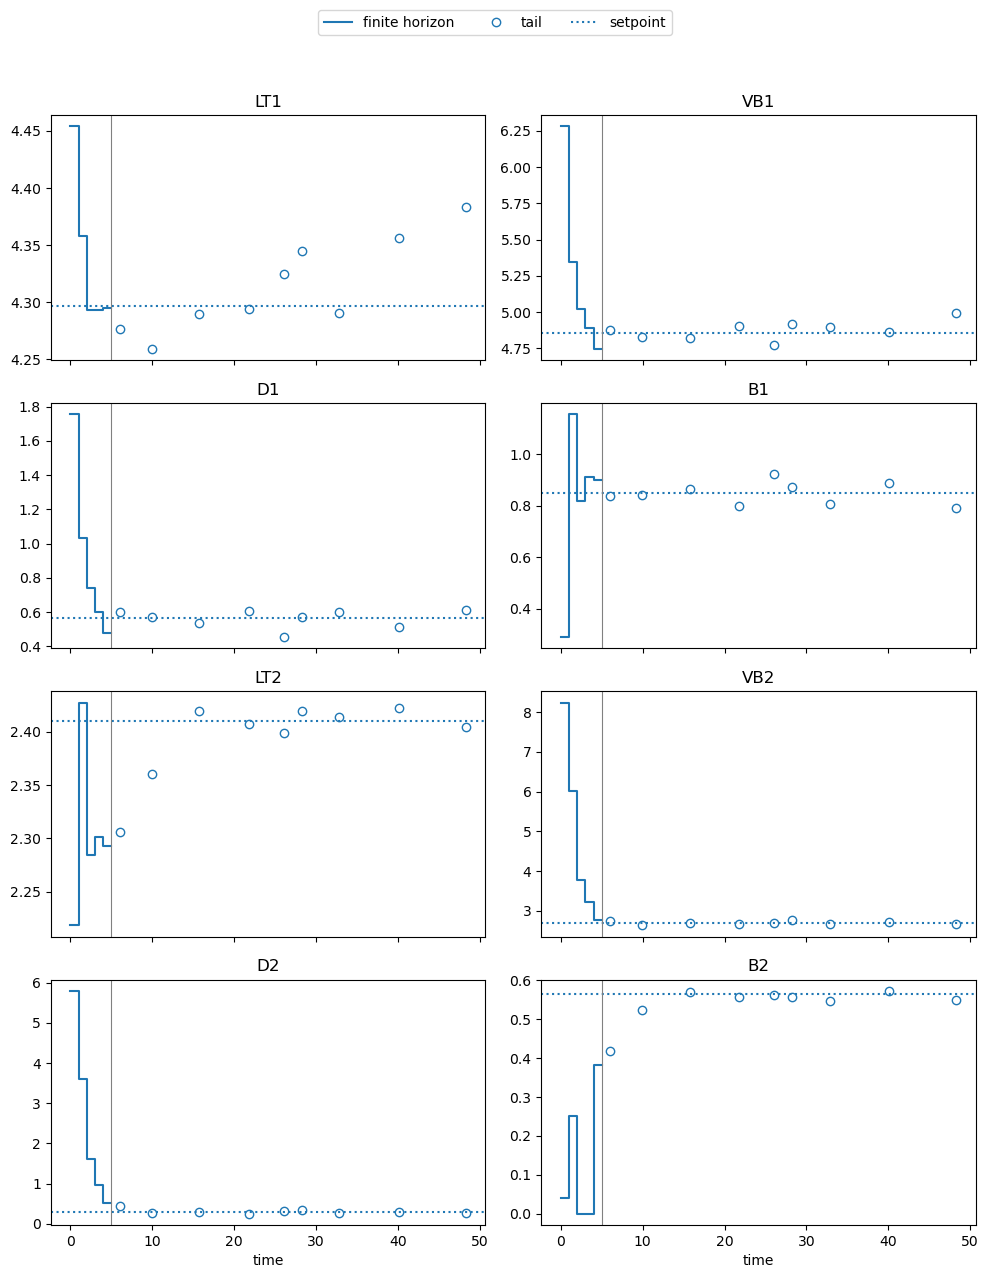

In [4]:
plot_controls(m1);

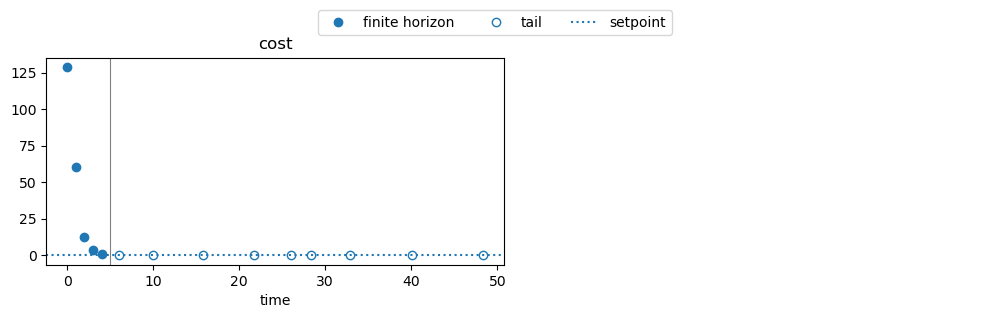

In [5]:
plot_stage_cost(m1);

## Case 2: twenty-five samples, finite horizon with the terminal cost

In [6]:
m2 = double_column(N=25)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=25, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
drto.cold_start_dynamic(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)
#pyo.SolverFactory("ipopt").solve(m2, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpi9gf8kdr.pyomo.nl...


Parsed 62166 vars, 61966 cons, jac_nnz=290486, h_nnz=145748 in 0.20s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   290486
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   145748

Total number of variables............................:    62166
                     variables with only lower bounds:     6156
                variables with lower and upper bounds:    37288
                     variables with only upper bounds:        0
Total number of equality constraints.................:    61966
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.6421478e+02 5.05e+00 1.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  5.6320844e+02 4.75e+00 4.95e+01   -1.0 1.56e+01      - 2.23e-01 5.94e-02f  1


   2  5.6637523e+02 4.41e+00 2.49e+02   -1.0 2.05e+01      - 2.96e-01 7.17e-02f  1


...

  87  2.0881656e+02 6.44e-08 9.56e-03   -5.7 7.44e-04      - 1.00e+00 1.00e+00h  1


  88  2.0881656e+02 8.12e-14 4.76e-09   -5.7 5.64e-07      - 1.00e+00 1.00e+00h  1


  89  2.0881655e+02 4.67e-08 7.98e-02   -8.6 5.57e-04      - 9.99e-01 1.00e+00h  1


iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  90  2.0881655e+02 5.68e-14 6.67e-11   -8.6 5.14e-08      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 90

                                   (scaled)                 (unscaled)
Objective...............:   2.0881655256813394e+02    2.0881655256813394e+02
Dual infeasibility......:   6.6682067424094990e-11    6.6682067424094990e-11
Constraint violation....:   5.6843418860808015e-14    5.6843418860808015e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059041974281022e-09    2.5059041974281022e-09
Overall NLP error.......:   2.5059041974281022e-09    2.5059041974281022e-09


Number of objective function evaluations             = 103
Number of objective gradient evaluations             = 91
Number of equality constraint evaluations            = 103
Number of inequality constraint evaluations          = 103
Number of equality constraint Ja

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 61966, 'Number of variables': 62166, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 196.27140259742737}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

<drto registry>
states: 580, controls: 8
declarations:
  horizon: t (ContinuousSet, 76 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[i,t]  ==  L1[11,t] - L1[i,t] + VB1[i] - VB1[i]  for i in tray, t in t
  dynamics: dx1[i,j,t]  ==  (L1[11,t]*(x1[11,j,t] - x1[i,j,t]) + VB1[i]*(y1[9,j,t] - x1[i,j,t]) - VB1[i]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t]  for i in tray, j in comp, t in t
  dynamics: dM2[i,t]  ==  L2[11,t] - L2[i,t] + VB2[i] - VB2[i]  for i in tray, t in t
  dynamics: dx2[i,j,t]  ==  (L2[11,t]*(x2[11,j,t] - x2[i,j,t]) + VB2[i]*(y2[9,j,t] - x2[i,j,t]) - VB2[i]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t]  for i in tray, j in comp, t in t
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray))  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(SUM((x1[i,j,25] - x1_ss[i,j])**2 + (x2[i,j,25] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,25] - M1_ss[l])**2 + (M2[l,25] - M2_ss[l])**2 for l in tray))
  initial conditions: x1_hat[i,j]  ==  x1[i,j,0]  for i in tray, j in comp
  initial conditions: x2_hat[i,j]  ==  x2[i,j,0]  for i in tray, j in comp
  initial conditions: M1_hat[i]  ==  M1[i,0]  for i in tray
  initial conditions: M2_hat[i]  ==  M2[i,0]  for i in tray
  steady-state targets: x1_ss (of x1), x2_ss (of x2), M1_ss (of M1), M2_ss (of M2)
  steady-state control targets: LT1_ss (of LT1), VB1_ss (of VB1), D1_ss (of D1), B1_ss (of B1), LT2_ss (of LT2), VB2_ss (of VB2), D2_ss (of D2), B2_ss (of B2)
transformations:
  drto.parameterize: profiles=LT1 (piecewise_constant), VB1 (piecewise_constant), D1 (piecewise_constant), B1 (piecewise_constant), LT2 (piecewise_constant), VB2 (piecewise_constant), D2 (piecewise_constant), B2 (piecewise_constant)
  drto.build_objective: objective=sum of 26 weighted cost terms

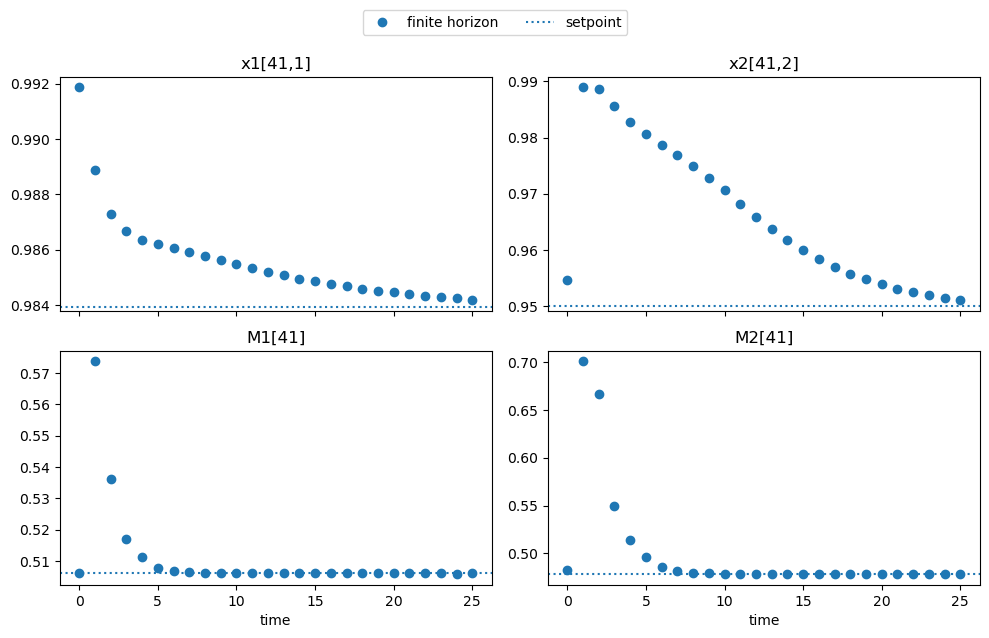

In [8]:
plot_states(m2, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

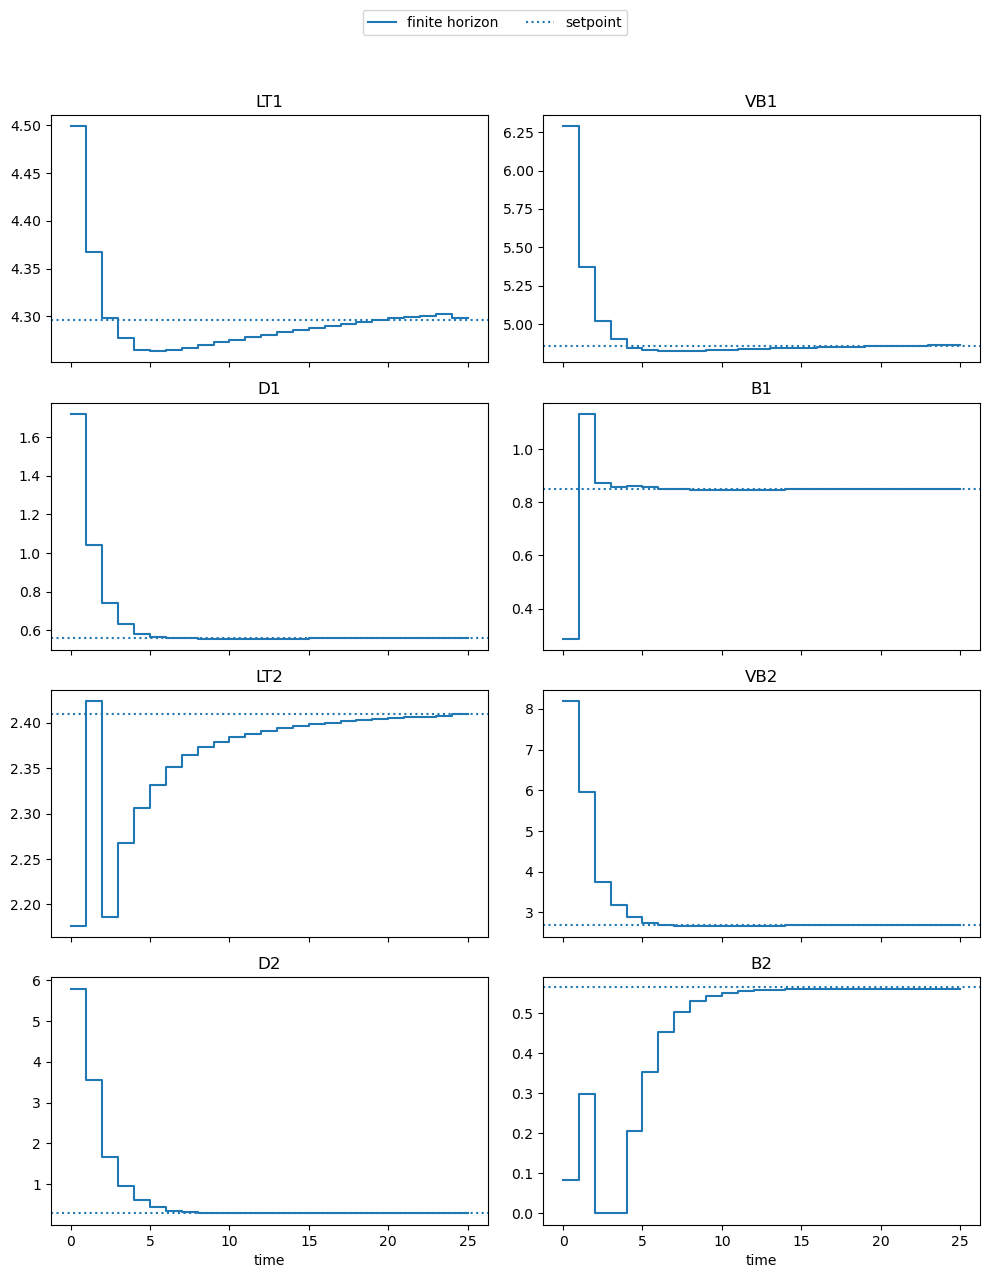

In [9]:
plot_controls(m2);

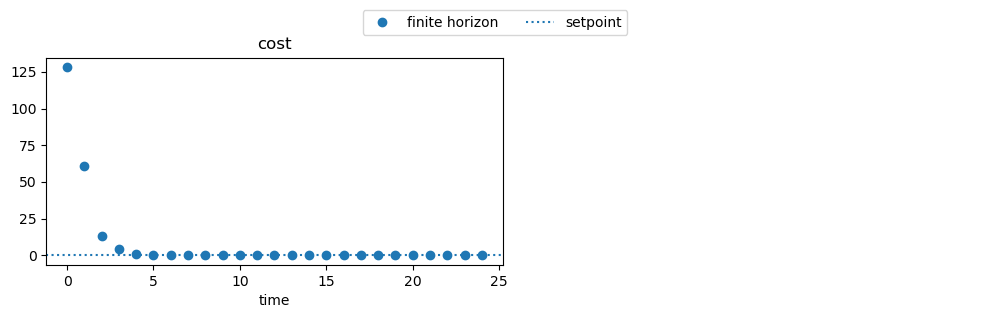

In [10]:
plot_stage_cost(m2);